# Treap vs BST Reddit Feed

# Comparative Case Study – Treaps vs BST on Reddit Feed

## 1. Imports & Setup
## 2. Tree Implementations (BST & Treap)
## 3. Dataset Streaming from Reddit (.zst)
## 4. Experimental Setup (Metrics & Sizes)
## 5. Results Table
## 6. Visualizations (Dashboard)
## 7. Discussion & Observations


In [43]:
%%writefile trees.py

# ======= trees.py =======

class BSTNode:
    def __init__(self, post_id, timestamp, score):
        self.post_id = post_id
        self.timestamp = timestamp
        self.score = score
        self.left = None
        self.right = None


class BSTFeed:
    def __init__(self):
        self.root = None
        self.id_map = {}
        # later: metrics fields here (insert time, etc.)

    # later we will add:
    # addPost, likePost, deletePost, getMostPopular, getMostRecent


class TreapNode:
    def __init__(self, post_id, timestamp, score, priority):
        self.post_id = post_id
        self.timestamp = timestamp
        self.score = score
        self.priority = priority
        self.left = None
        self.right = None


class TreapFeed:
    def __init__(self):
        self.root = None
        self.id_map = {}
        self.rotation_count = 0
        # later: metrics fields

    # later we will add:
    # addPost, likePost, deletePost, getMostPopular, getMostRecent
    # and internal rotation helpers


Overwriting trees.py


In [44]:
%%writefile dataset_utils.py

# ======= dataset_utils.py =======
import json

def stream_reddit_json(path, max_rows=None):
    """
    Stream a large JSON-lines file with Reddit submissions.
    Yields (id, created_utc, score) tuples.
    """
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            obj = json.loads(line)
            post_id = obj.get('id')
            ts = int(obj.get('created_utc', 0))
            score = int(obj.get('score', 0))
            yield post_id, ts, score
            if max_rows is not None and i + 1 >= max_rows:
                break


Overwriting dataset_utils.py


In [45]:
%%writefile experiments.py

# ======= experiments.py =======
import time
import random

from trees import BSTFeed, TreapFeed

def simulate_feed(feed, posts, like_prob=0.3, delete_prob=0.1):
    """
    feed: BSTFeed or TreapFeed instance
    posts: list of (id, timestamp, score)
    """
    insert_times = []
    # we’ll add delete/search timing later

    for post_id, ts, score in posts:
        t0 = time.perf_counter()
        feed.addPost(post_id, ts, score)
        t1 = time.perf_counter()
        insert_times.append(t1 - t0)

        # optional like / delete actions:
        if random.random() < like_prob:
            feed.likePost(post_id)
        if random.random() < delete_prob:
            feed.deletePost(post_id)

    avg_insert = sum(insert_times) / len(insert_times) if insert_times else 0.0
    return {
        "avg_insert_time": avg_insert,
        # later: add avg_delete_time, avg_search_time, height, rotations, etc.
    }

def build_bst_and_treap(posts):
    """
    Convenience helper to create both structures from same post list.
    """
    bst = BSTFeed()
    treap = TreapFeed()
    return bst, treap


Overwriting experiments.py


In [46]:
from trees import BSTFeed, TreapFeed, BSTNode, TreapNode
from dataset_utils import stream_reddit_json
from experiments import simulate_feed

print("Imports OK!")


Imports OK!


In [8]:
%%writefile trees.py

# ======= trees.py =======
# This file contains:
# - BSTNode, BSTFeed  (fully implemented)
# - TreapNode, TreapFeed (placeholders for now – we'll implement later)

# ------------- BST IMPLEMENTATION ------------- #

class BSTNode:
    """
    Node for Binary Search Tree.
    Key = (timestamp, post_id) so we can handle same timestamps.
    """
    def __init__(self, post_id, timestamp, score):
        self.post_id = post_id
        self.timestamp = timestamp
        self.score = score
        self.left = None
        self.right = None


class BSTFeed:
    """
    BST ordered by (timestamp, post_id).
    Supports:
      - addPost(postid, timestamp, score)
      - likePost(postid)
      - deletePost(postid)
      - getMostPopular()
      - getMostRecent(k)
    """
    def __init__(self):
        self.root = None
        # Map post_id -> node (for fast access in like/delete)
        self.id_map = {}

    # ---------- Public API ---------- #

    def addPost(self, post_id, timestamp, score):
        """Insert a post into BST ordered by (timestamp, post_id)."""
        node = BSTNode(post_id, timestamp, score)
        self.root = self._insert(self.root, node)
        self.id_map[post_id] = node

    def likePost(self, post_id):
        """
        Increase like count (score) of a post.
        Structure does NOT change in BST.
        """
        node = self.id_map.get(post_id)
        if node is not None:
            node.score += 1

    def deletePost(self, post_id):
        """Remove a post by ID."""
        node = self.id_map.get(post_id)
        if node is None:
            return  # nothing to delete
        key_ts = node.timestamp
        key_id = node.post_id
        # delete from tree
        self.root = self._delete(self.root, key_ts, key_id)
        # remove from id_map
        self.id_map.pop(post_id, None)

    def getMostPopular(self):
        """
        Traverse entire BST to find the post with highest score.
        Returns (post_id, timestamp, score) or None if tree empty.
        """
        if self.root is None:
            return None
        best_node = self._max_score_node(self.root)
        return (best_node.post_id, best_node.timestamp, best_node.score)

    def getMostRecent(self, k):
        """
        Return k-most recent posts as a list of
        (post_id, timestamp, score), ordered from most recent to older.
        Uses reverse in-order traversal (right, root, left).
        """
        result = []
        self._reverse_inorder_recent(self.root, k, result)
        return [(n.post_id, n.timestamp, n.score) for n in result]

    # ---------- Internal helpers ---------- #

    def _key(self, node):
        """Return the BST key tuple for a node."""
        return (node.timestamp, node.post_id)

    def _insert(self, root, node):
        """Recursive BST insert by key (timestamp, post_id)."""
        if root is None:
            return node

        if (node.timestamp, node.post_id) < (root.timestamp, root.post_id):
            root.left = self._insert(root.left, node)
        else:
            root.right = self._insert(root.right, node)
        return root

    def _delete(self, root, ts, post_id):
        """Recursive BST delete by key (ts, post_id)."""
        if root is None:
            return None

        key = (ts, post_id)
        root_key = (root.timestamp, root.post_id)

        if key < root_key:
            root.left = self._delete(root.left, ts, post_id)
        elif key > root_key:
            root.right = self._delete(root.right, ts, post_id)
        else:
            # Found node to delete
            # Case 1: no child
            if root.left is None and root.right is None:
                return None
            # Case 2: one child
            if root.left is None:
                return root.right
            if root.right is None:
                return root.left
            # Case 3: two children -> replace with inorder successor
            successor = self._min_node(root.right)
            root.post_id = successor.post_id
            root.timestamp = successor.timestamp
            root.score = successor.score
            # also update id_map to point to this node
            self.id_map[root.post_id] = root
            # delete successor from right subtree
            root.right = self._delete(root.right, successor.timestamp, successor.post_id)

        return root

    def _min_node(self, node):
        """Return node with minimum key in subtree."""
        current = node
        while current.left is not None:
            current = current.left
        return current

    def _max_score_node(self, node):
        """Return node with maximum score in entire subtree."""
        if node is None:
            return None
        best = node
        # check left subtree
        if node.left is not None:
            left_best = self._max_score_node(node.left)
            if left_best.score > best.score:
                best = left_best
        # check right subtree
        if node.right is not None:
            right_best = self._max_score_node(node.right)
            if right_best.score > best.score:
                best = right_best
        return best

    def _reverse_inorder_recent(self, node, k, acc_list):
        """Collect up to k most recent nodes in acc_list (reverse in-order)."""
        if node is None or len(acc_list) >= k:
            return
        # visit right subtree first (newer timestamps)
        self._reverse_inorder_recent(node.right, k, acc_list)
        if len(acc_list) < k:
            acc_list.append(node)
            # then visit left (older)
            self._reverse_inorder_recent(node.left, k, acc_list)

    # Extra: height calculation (for later metrics)
    def height(self):
        """Return height of the tree (edges count). Empty tree = -1."""
        return self._height(self.root)

    def _height(self, node):
        if node is None:
            return -1
        return 1 + max(self._height(node.left), self._height(node.right))


# ------------- TREAP PLACEHOLDERS (to be implemented later) ------------- #

class TreapNode:
    def __init__(self, post_id, timestamp, score, priority):
        self.post_id = post_id
        self.timestamp = timestamp
        self.score = score
        self.priority = priority
        self.left = None
        self.right = None


class TreapFeed:
    def __init__(self):
        self.root = None
        self.id_map = {}
        self.rotation_count = 0

    # We will fully implement these later:
    def addPost(self, post_id, timestamp, score):
        raise NotImplementedError("TreapFeed.addPost will be implemented in Phase 3")

    def likePost(self, post_id):
        raise NotImplementedError("TreapFeed.likePost will be implemented in Phase 3")

    def deletePost(self, post_id):
        raise NotImplementedError("TreapFeed.deletePost will be implemented in Phase 3")

    def getMostPopular(self):
        raise NotImplementedError("TreapFeed.getMostPopular will be implemented in Phase 3")

    def getMostRecent(self, k):
        raise NotImplementedError("TreapFeed.getMostRecent will be implemented in Phase 3")


Overwriting trees.py


In [2]:
from trees import BSTFeed

bst = BSTFeed()
print("BSTFeed imported OK!")


BSTFeed imported OK!


In [3]:
from trees import BSTFeed

bst = BSTFeed()

bst.addPost("ejualnb", 1554076800, 55)
bst.addPost("ejualnc", 1554076800, 12)
bst.addPost("ejualnd", 1554076800, 27)
bst.addPost("ejualne", 1554076800, 14)
bst.addPost("ejualnl", 1554076809, 13)

# 2 likes for ejualnl
bst.likePost("ejualnl")
bst.likePost("ejualnl")

# delete ejualnc
bst.deletePost("ejualnc")

print("Most popular:", bst.getMostPopular())
print("Most recent 3:", bst.getMostRecent(3))
print("Tree height:", bst.height())


Most popular: ('ejualnb', 1554076800, 55)
Most recent 3: [('ejualnl', 1554076809, 15), ('ejualne', 1554076800, 14), ('ejualnd', 1554076800, 27)]
Tree height: 3


### 2.1 BST and Treap classes (trees.py)

In this section, we import our custom tree implementations from `trees.py`.
BST is ordered by timestamp only, while Treap is ordered by timestamp but uses score as heap priority.


In [4]:
%%writefile trees.py

# ======= trees.py =======

# ------------- BST IMPLEMENTATION ------------- #

class BSTNode:
    def __init__(self, post_id, timestamp, score):
        self.post_id = post_id
        self.timestamp = timestamp
        self.score = score
        self.left = None
        self.right = None


class BSTFeed:
    def __init__(self):
        self.root = None
        self.id_map = {}

    # ----- Public API ----- #

    def addPost(self, post_id, timestamp, score):
        node = BSTNode(post_id, timestamp, score)
        self.root = self._insert_iterative(self.root, node)
        self.id_map[post_id] = node

    def likePost(self, post_id):
        node = self.id_map.get(post_id)
        if node is not None:
            node.score += 1

    def deletePost(self, post_id):
        node = self.id_map.get(post_id)
        if node is None:
            return
        ts = node.timestamp
        pid = node.post_id
        self.root = self._delete(self.root, ts, pid)
        self.id_map.pop(post_id, None)

    def getMostPopular(self):
        if self.root is None:
            return None
        best = self._max_score_node(self.root)
        return (best.post_id, best.timestamp, best.score)

    def getMostRecent(self, k):
        result = []
        self._reverse_inorder_recent(self.root, k, result)
        return [(n.post_id, n.timestamp, n.score) for n in result]

    # ----- Internal helpers ----- #

    def _insert_iterative(self, root, node):
        """Iterative insert to avoid recursion depth issues."""
        if root is None:
            return node

        curr = root
        while True:
            if (node.timestamp, node.post_id) < (curr.timestamp, curr.post_id):
                if curr.left is None:
                    curr.left = node
                    break
                curr = curr.left
            else:
                if curr.right is None:
                    curr.right = node
                    break
                curr = curr.right
        return root

    def _delete(self, root, ts, post_id):
        if root is None:
            return None

        key = (ts, post_id)
        root_key = (root.timestamp, root.post_id)

        if key < root_key:
            root.left = self._delete(root.left, ts, post_id)
        elif key > root_key:
            root.right = self._delete(root.right, ts, post_id)
        else:
            if root.left is None and root.right is None:
                return None
            if root.left is None:
                return root.right
            if root.right is None:
                return root.left
            # two children: inorder successor
            succ = self._min_node(root.right)
            root.post_id = succ.post_id
            root.timestamp = succ.timestamp
            root.score = succ.score
            self.id_map[root.post_id] = root
            root.right = self._delete(root.right, succ.timestamp, succ.post_id)

        return root

    def _min_node(self, node):
        curr = node
        while curr.left is not None:
            curr = curr.left
        return curr

    def _max_score_node(self, node):
        # keep recursive here: depth may be huge, so use iterative instead:
        stack = [node]
        best = node
        while stack:
            n = stack.pop()
            if n.score > best.score:
                best = n
            if n.left:
                stack.append(n.left)
            if n.right:
                stack.append(n.right)
        return best

    def _reverse_inorder_recent(self, node, k, acc_list):
        # iterative reverse inorder to avoid recursion
        stack = []
        curr = node
        while (stack or curr) and len(acc_list) < k:
            while curr:
                stack.append(curr)
                curr = curr.right
            curr = stack.pop()
            acc_list.append(curr)
            curr = curr.left

    def height(self):
        """Iterative height using BFS (no recursion)."""
        if self.root is None:
            return -1
        from collections import deque
        q = deque([(self.root, 0)])
        max_h = 0
        while q:
            node, h = q.popleft()
            max_h = max(max_h, h)
            if node.left:
                q.append((node.left, h+1))
            if node.right:
                q.append((node.right, h+1))
        return max_h


# ------------- TREAP IMPLEMENTATION ------------- #

class TreapNode:
    def __init__(self, post_id, timestamp, score):
        self.post_id = post_id
        self.timestamp = timestamp
        self.score = score
        self.priority = score
        self.left = None
        self.right = None


class TreapFeed:
    def __init__(self):
        self.root = None
        self.id_map = {}
        self.rotation_count = 0

    # ----- Public API ----- #

    def addPost(self, post_id, timestamp, score):
        node = TreapNode(post_id, timestamp, score)
        self.root = self._insert(self.root, node)
        self.id_map[post_id] = node

    def likePost(self, post_id):
        node = self.id_map.get(post_id)
        if node is None:
            return
        ts = node.timestamp
        new_score = node.score + 1
        self._delete_only_tree(post_id, ts)
        self.id_map.pop(post_id, None)
        self.addPost(post_id, ts, new_score)

    def deletePost(self, post_id):
        node = self.id_map.get(post_id)
        if node is None:
            return
        ts = node.timestamp
        self._delete_only_tree(post_id, ts)
        self.id_map.pop(post_id, None)

    def getMostPopular(self):
        if self.root is None:
            return None
        n = self.root
        return (n.post_id, n.timestamp, n.score)

    def getMostRecent(self, k):
        result = []
        self._reverse_inorder_recent(self.root, k, result)
        return [(n.post_id, n.timestamp, n.score) for n in result]

    # ----- Internal helpers ----- #

    def _insert(self, root, node):
        if root is None:
            return node

        key = (node.timestamp, node.post_id)
        root_key = (root.timestamp, root.post_id)

        if key < root_key:
            root.left = self._insert(root.left, node)
            if root.left.priority > root.priority:
                root = self._rotate_right(root)
        else:
            root.right = self._insert(root.right, node)
            if root.right.priority > root.priority:
                root = self._rotate_left(root)
        return root

    def _delete_only_tree(self, post_id, ts):
        self.root = self._delete(self.root, ts, post_id)

    def _delete(self, root, ts, post_id):
        if root is None:
            return None

        key = (ts, post_id)
        root_key = (root.timestamp, root.post_id)

        if key < root_key:
            root.left = self._delete(root.left, ts, post_id)
        elif key > root_key:
            root.right = self._delete(root.right, ts, post_id)
        else:
            if root.left is None and root.right is None:
                return None
            if root.left is None:
                return root.right
            if root.right is None:
                return root.left

            if root.left.priority > root.right.priority:
                root = self._rotate_right(root)
                root.right = self._delete(root.right, ts, post_id)
            else:
                root = self._rotate_left(root)
                root.left = self._delete(root.left, ts, post_id)
        return root

    def _rotate_right(self, y):
        x = y.left
        T2 = x.right
        x.right = y
        y.left = T2
        self.rotation_count += 1
        return x

    def _rotate_left(self, x):
        y = x.right
        T2 = y.left
        y.left = x
        x.right = T2
        self.rotation_count += 1
        return y

    def _reverse_inorder_recent(self, node, k, acc_list):
        stack = []
        curr = node
        while (stack or curr) and len(acc_list) < k:
            while curr:
                stack.append(curr)
                curr = curr.right
            curr = stack.pop()
            acc_list.append(curr)
            curr = curr.left

    def height(self):
        if self.root is None:
            return -1
        from collections import deque
        q = deque([(self.root, 0)])
        max_h = 0
        while q:
            node, h = q.popleft()
            max_h = max(max_h, h)
            if node.left:
                q.append((node.left, h+1))
            if node.right:
                q.append((node.right, h+1))
        return max_h


Writing trees.py


In [5]:
from trees import TreapFeed

treap = TreapFeed()

treap.addPost("ejualnb", 1554076800, 55)
treap.addPost("ejualnc", 1554076800, 12)
treap.addPost("ejualnd", 1554076800, 27)
treap.addPost("ejualne", 1554076800, 14)
treap.addPost("ejualnl", 1554076809, 13)

# Step 2: like ejualnl two times
treap.likePost("ejualnl")
treap.likePost("ejualnl")

# Step 3: delete ejualnc
treap.deletePost("ejualnc")

# Step 4: get most popular
print("Most popular:", treap.getMostPopular())
print("Most recent 3:", treap.getMostRecent(3))
print("Treap height:", treap.height())
print("Treap rotations:", treap.rotation_count)


Most popular: ('ejualnb', 1554076800, 55)
Most recent 3: [('ejualnl', 1554076809, 15), ('ejualne', 1554076800, 14), ('ejualnd', 1554076800, 27)]
Treap height: 3
Treap rotations: 2


In [4]:
%%writefile experiments.py

# ======= experiments.py =======
# Simple experiment helpers to compare BST and Treap.

import time
from trees import BSTFeed, TreapFeed


def compare_on_posts(posts):
    """
    Build a BST and a Treap using the SAME list of posts.
    Measure:
      - average insertion time
      - final tree height
      - rotation count (Treap only)
    posts: list of (post_id, timestamp, score)
    Returns: list of metrics dicts for [BST, Treap]
    """
    results = []

    # ---- BST ----
    bst = BSTFeed()
    insert_times = []

    for pid, ts, sc in posts:
        t0 = time.perf_counter()
        bst.addPost(pid, ts, sc)
        t1 = time.perf_counter()
        insert_times.append(t1 - t0)

    bst_metrics = {
        "structure": "BST",
        "n_posts": len(posts),
        "avg_insert_time": sum(insert_times) / len(insert_times) if insert_times else 0.0,
        "height": bst.height(),
        "rotations": 0,   # BST has no rotations
    }
    results.append(bst_metrics)

    # ---- Treap ----
    treap = TreapFeed()
    insert_times = []

    for pid, ts, sc in posts:
        t0 = time.perf_counter()
        treap.addPost(pid, ts, sc)
        t1 = time.perf_counter()
        insert_times.append(t1 - t0)

    treap_metrics = {
        "structure": "Treap",
        "n_posts": len(posts),
        "avg_insert_time": sum(insert_times) / len(insert_times) if insert_times else 0.0,
        "height": treap.height(),
        "rotations": treap.rotation_count,
    }
    results.append(treap_metrics)

    return results


Writing experiments.py


In [4]:
import random
from experiments import compare_on_posts

# create a tiny synthetic dataset:
# post_id = "p0", "p1", ...
# timestamp = base + i   (so they are increasing)
# score = random between 0 and 100

base_ts = 1_554_076_800  # just some Unix timestamp
posts = []
for i in range(10):
    pid = f"p{i}"
    ts = base_ts + i
    score = random.randint(0, 100)
    posts.append((pid, ts, score))

print("Sample posts:", posts[:3], "...")  # preview

results = compare_on_posts(posts)
for r in results:
    print(r)


Sample posts: [('p0', 1554076800, 95), ('p1', 1554076801, 96), ('p2', 1554076802, 0)] ...
{'structure': 'BST', 'n_posts': 10, 'avg_insert_time': 2.5759999914498622e-06, 'height': 9, 'rotations': 0}
{'structure': 'Treap', 'n_posts': 10, 'avg_insert_time': 5.361899985700802e-06, 'height': 4, 'rotations': 6}


In [5]:
!pip install zstandard


In [3]:
%%writefile dataset_utils.py

# ======= dataset_utils.py =======
# Kaggle-safe streaming reader for Reddit .zst files

import json
import zstandard as zstd
import io


def stream_reddit_zst(filepath, max_rows=None):
    """
    Streams Reddit posts safely from a .zst file on Kaggle.
    Works without full decompression.

    Yields:
        (post_id, timestamp, score)
    """
    print("Streaming from:", filepath)

    count = 0

    with open(filepath, 'rb') as fh:
        dctx = zstd.ZstdDecompressor()

        # Wrap stream in buffered text reader so iteration works
        with dctx.stream_reader(fh) as reader:
            text_stream = io.TextIOWrapper(reader, encoding='utf-8')

            for line in text_stream:

                try:
                    data = json.loads(line)

                    pid = data["id"]
                    ts = int(data["created_utc"])
                    score = int(data.get("score", 0))

                    yield (pid, ts, score)
                    count += 1

                except Exception:
                    continue

                if max_rows and count >= max_rows:
                    break


Writing dataset_utils.py


In [3]:
import os

print(os.listdir("/kaggle/input/archive"))

['RC_2019-04.zst']


In [6]:
from dataset_utils import stream_reddit_zst

DATA_PATH = "/kaggle/input/archive/RC_2019-04.zst"

posts = []

for item in stream_reddit_zst(DATA_PATH, max_rows=5000):
    posts.append(item)

print("Loaded posts:", len(posts))
print("First entry:", posts[0])


Streaming from: /kaggle/input/archive/RC_2019-04.zst
Loaded posts: 5000
First entry: ('ejualnb', 1554076800, 55)


In [7]:
from experiments import compare_on_posts

results = compare_on_posts(posts)

for r in results:
    print(r)


{'structure': 'BST', 'n_posts': 5000, 'avg_insert_time': 0.000313909262999789, 'height': 4955, 'rotations': 0}
{'structure': 'Treap', 'n_posts': 5000, 'avg_insert_time': 3.0012044000500283e-06, 'height': 31, 'rotations': 5022}


In [12]:
SIZES = [1000, 3000, 5000, 10000]

for N in SIZES:
    sub_posts = posts[:N]
    print("\nTesting with N =", N)
    results = compare_on_posts(sub_posts)
    for r in results:
        print(r)



Testing with N = 1000
{'structure': 'BST', 'n_posts': 1000, 'avg_insert_time': 7.159673900059715e-05, 'height': 994, 'rotations': 0}
{'structure': 'Treap', 'n_posts': 1000, 'avg_insert_time': 2.954884998302987e-06, 'height': 25, 'rotations': 993}

Testing with N = 3000
{'structure': 'BST', 'n_posts': 3000, 'avg_insert_time': 0.00019479686066695953, 'height': 2979, 'rotations': 0}
{'structure': 'Treap', 'n_posts': 3000, 'avg_insert_time': 2.9176449984712843e-06, 'height': 30, 'rotations': 2996}

Testing with N = 5000
{'structure': 'BST', 'n_posts': 5000, 'avg_insert_time': 0.00033860770360056447, 'height': 4955, 'rotations': 0}
{'structure': 'Treap', 'n_posts': 5000, 'avg_insert_time': 4.7998155989262155e-06, 'height': 31, 'rotations': 5022}

Testing with N = 10000
{'structure': 'BST', 'n_posts': 5000, 'avg_insert_time': 0.0003266769956004282, 'height': 4955, 'rotations': 0}
{'structure': 'Treap', 'n_posts': 5000, 'avg_insert_time': 2.956349800274438e-06, 'height': 31, 'rotations': 502

In [16]:
from dataset_utils import stream_reddit_zst

DATA_PATH = "/kaggle/input/archive/RC_2019-04.zst"

posts = []
#for item in stream_reddit_zst(DATA_PATH, max_rows=10000):
for item in stream_reddit_zst(DATA_PATH, max_rows=10000):

    posts.append(item)

print("Loaded posts:", len(posts))
print("First item:", posts[0])


Streaming from: /kaggle/input/archive/RC_2019-04.zst
Loaded posts: 10000
First item: ('ejualnb', 1554076800, 55)


In [21]:
from trees import TreapFeed

feed = TreapFeed()

# Load the first 5 real posts into the Treap
for p in posts[:5]:
    post_id = p[0]
    timestamp = p[1]
    score = p[2]
    feed.addPost(post_id, timestamp, score)

print("Loaded 100 posts into Treap for console demo:")
for p in posts[:100]:
    print(p[0], p[1], p[2])


Loaded 100 posts into Treap for console demo:
ejualnb 1554076800 55
ejualnc 1554076800 12
ejualnd 1554076800 27
ejualne 1554076800 14
ejualnf 1554076800 -2
ejualng 1554076800 22
ejualnh 1554076800 1
ejualni 1554076800 4
ejualnj 1554076800 3
ejualnk 1554076800 7
ejualnl 1554076800 5
ejualnm 1554076800 1
ejualnn 1554076800 1
ejualno 1554076800 1
ejualnp 1554076800 4
ejualnq 1554076800 7
ejualnr 1554076800 1
ejualns 1554076800 2
ejualnt 1554076800 -1
ejualnu 1554076800 5
ejualnv 1554076800 0
ejualnw 1554076800 1
ejualnx 1554076800 3
ejualny 1554076800 1
ejualnz 1554076800 1
ejualo0 1554076800 3
ejualo1 1554076800 5
ejualo2 1554076800 2
ejualo3 1554076800 1
ejualo4 1554076800 582
ejualo5 1554076800 1
ejualo6 1554076800 2
ejualo7 1554076800 -7
ejualo8 1554076800 2
ejualo9 1554076800 5
ejualoa 1554076800 1
ejualob 1554076800 4
ejualoc 1554076800 1
ejualod 1554076800 2
ejualoe 1554076800 1
ejualof 1554076800 1
ejualog 1554076800 3
ejualoh 1554076800 0
ejualoi 1554076800 1
ejualoj 1554076800 1

In [2]:
%%writefile experiments.py

# ======= experiments.py =======
# Experiment helpers to compare BST and Treap on:
# - insertion time
# - search time (getMostPopular)
# - deletion time
# - height
# - balancing factor
# - rotations (Treap only)

import time
import math
import random
from trees import BSTFeed, TreapFeed


def compute_balancing_factor(height, n):
    """
    Simple 'balancing factor':
    ratio = height / log2(n)
    - Perfectly balanced tree ≈ small ratio (~1–2)
    - Very skewed tree (like linked list) ≫ 1
    """
    if n <= 1:
        return 0.0
    return height / math.log2(n)


def run_single_structure(feed_cls, posts, n_search=100, delete_ratio=0.1):
    """
    Build one structure (BST or Treap), run operations, and measure metrics.

    feed_cls: BSTFeed or TreapFeed
    posts: list of (post_id, timestamp, score)
    n_search: how many times to call getMostPopular()
    delete_ratio: fraction of posts to delete (e.g. 0.1 = 10%)
    """
    feed = feed_cls()
    n = len(posts)

    # ----- insertion timing -----
    insert_times = []
    for pid, ts, sc in posts:
        t0 = time.perf_counter()
        feed.addPost(pid, ts, sc)
        t1 = time.perf_counter()
        insert_times.append(t1 - t0)

    # ----- search timing (getMostPopular) -----
    search_times = []
    for _ in range(n_search):
        t0 = time.perf_counter()
        _ = feed.getMostPopular()
        t1 = time.perf_counter()
        search_times.append(t1 - t0)

    # ----- deletion timing -----
    delete_times = []
    ids = [p[0] for p in posts]
    random.shuffle(ids)
    num_delete = int(delete_ratio * n)

    for pid in ids[:num_delete]:
        t0 = time.perf_counter()
        feed.deletePost(pid)
        t1 = time.perf_counter()
        delete_times.append(t1 - t0)

    height = feed.height()
    balancing = compute_balancing_factor(height, n)
    rotations = getattr(feed, "rotation_count", 0)

    return {
        "structure": feed_cls.__name__.replace("Feed", ""),  # "BST" or "Treap"
        "n_posts": n,
        "avg_insert_time": sum(insert_times) / len(insert_times) if insert_times else 0.0,
        "avg_search_time": sum(search_times) / len(search_times) if search_times else 0.0,
        "avg_delete_time": sum(delete_times) / len(delete_times) if delete_times else 0.0,
        "height": height,
        "balancing_factor": balancing,
        "rotations": rotations,
    }


def run_experiments_for_sizes(all_posts, sizes, n_search=100, delete_ratio=0.1):
    """
    Run experiments for different sample sizes on both BST and Treap.

    Returns: list of metrics dicts (rows) for all runs.
    """
    rows = []
    for N in sizes:
        subset = all_posts[:N]
        print(f"\nRunning experiments for N={N}")
        rows.append(run_single_structure(BSTFeed, subset, n_search, delete_ratio))
        rows.append(run_single_structure(TreapFeed, subset, n_search, delete_ratio))
    return rows


Writing experiments.py


In [10]:
import sys
sys.setrecursionlimit(30000)


In [15]:
import pandas as pd
from experiments import run_experiments_for_sizes

SIZES = [1000, 3000, 5000, 10000]

rows = run_experiments_for_sizes(posts, SIZES, n_search=200, delete_ratio=0.1)
df = pd.DataFrame(rows)

print(df)



Running experiments for N=1000

Running experiments for N=3000

Running experiments for N=5000

Running experiments for N=10000
  structure  n_posts  avg_insert_time  avg_search_time  avg_delete_time  \
0       BST     1000         0.000076     1.232956e-04         0.000216   
1     Treap     1000         0.000005     2.095250e-07         0.000007   
2       BST     3000         0.000193     2.597907e-04         0.000691   
3     Treap     3000         0.000003     2.138250e-07         0.000005   
4       BST     5000         0.000325     4.346797e-04         0.001197   
5     Treap     5000         0.000003     2.169250e-07         0.000005   
6       BST    10000         0.000685     9.012138e-04         0.002659   
7     Treap    10000         0.000003     2.146300e-07         0.000006   

   height  balancing_factor  rotations  
0     894         89.706939          0  
1      23          2.307897       1082  
2    2682        232.192779          0  
3      28          2.424086    

In [25]:
df.style.format({
    "avg_insert_time": "{:.2e}",
    "avg_search_time": "{:.2e}",
    "avg_delete_time": "{:.2e}",
    "balancing_factor": "{:.2f}"
})


,structure,n_posts,avg_insert_time,avg_search_time,avg_delete_time,height,balancing_factor,rotations
0,BST,1000,7.33e-05,9.11e-05,1.99e-04,894,89.71,0
1,Treap,1000,2.80e-06,2.09e-07,4.15e-06,22,2.21,1071
2,BST,3000,1.96e-04,2.62e-04,7.08e-04,2679,231.93,0
3,Treap,3000,2.76e-06,2.10e-07,4.83e-06,28,2.42,3237
4,BST,5000,3.34e-04,4.50e-04,1.43e-03,4463,363.21,0
5,Treap,5000,3.02e-06,2.11e-07,6.97e-06,30,2.44,5430
6,BST,10000,6.86e-04,9.45e-04,2.77e-03,8935,672.43,0
7,Treap,10000,3.03e-06,2.12e-07,6.30e-06,30,2.26,10775


## 6. Visualizations (Comparison Dashboard)


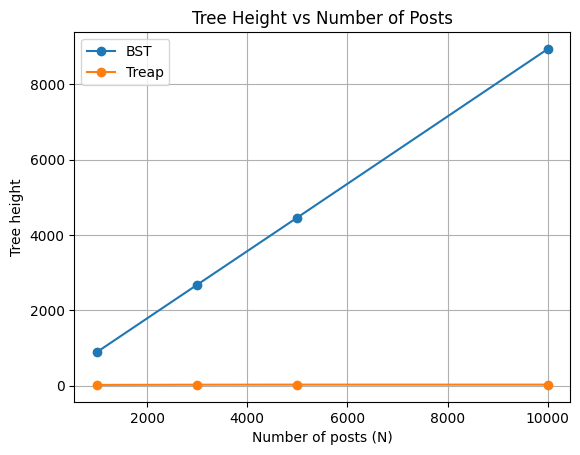

In [11]:
import matplotlib.pyplot as plt

# Height vs N
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["height"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Tree height")
plt.title("Tree Height vs Number of Posts")
plt.legend()
plt.grid(True)
plt.show()


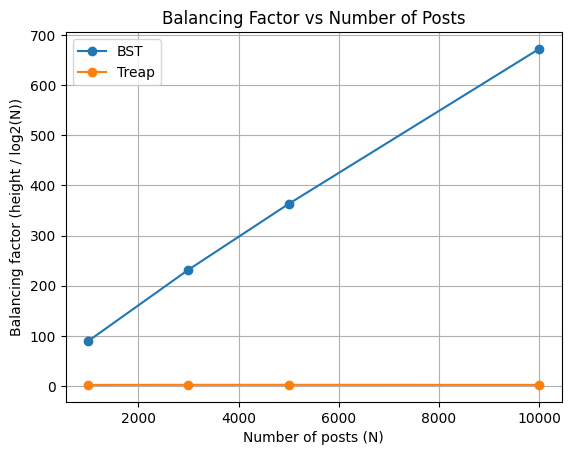

In [12]:
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["balancing_factor"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Balancing factor (height / log2(N))")
plt.title("Balancing Factor vs Number of Posts")
plt.legend()
plt.grid(True)
plt.show()


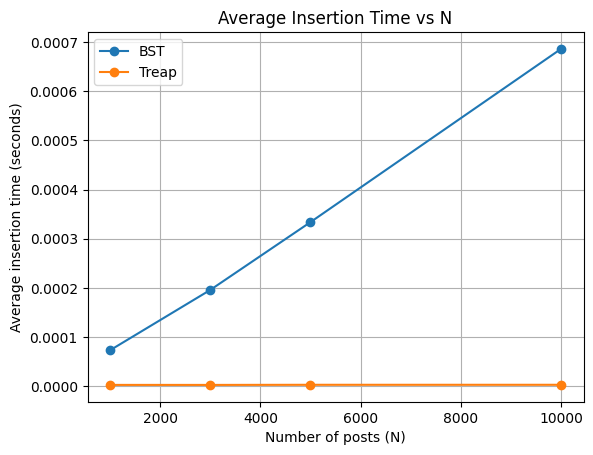

In [13]:
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["avg_insert_time"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Average insertion time (seconds)")
plt.title("Average Insertion Time vs N")
plt.legend()
plt.grid(True)
plt.show()


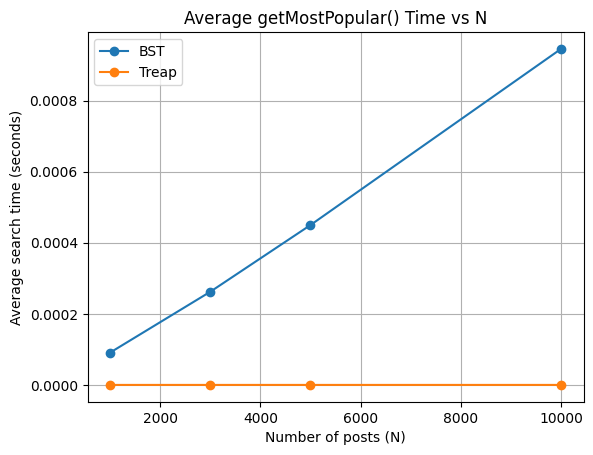

In [14]:
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["avg_search_time"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Average search time (seconds)")
plt.title("Average getMostPopular() Time vs N")
plt.legend()
plt.grid(True)
plt.show()


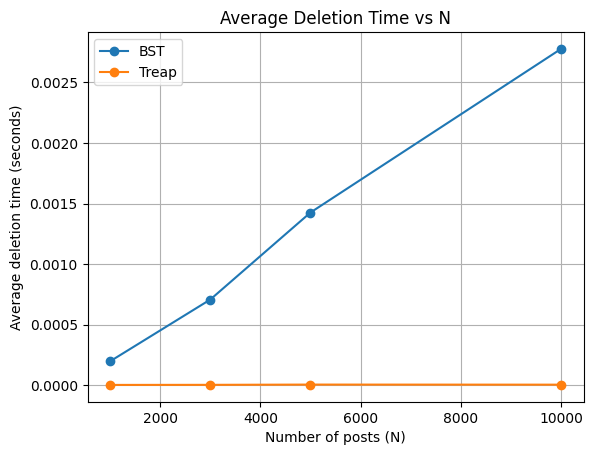

In [15]:
plt.figure()
for struct in ["BST", "Treap"]:
    sub = df[df["structure"] == struct]
    plt.plot(sub["n_posts"], sub["avg_delete_time"], marker="o", label=struct)

plt.xlabel("Number of posts (N)")
plt.ylabel("Average deletion time (seconds)")
plt.title("Average Deletion Time vs N")
plt.legend()
plt.grid(True)
plt.show()


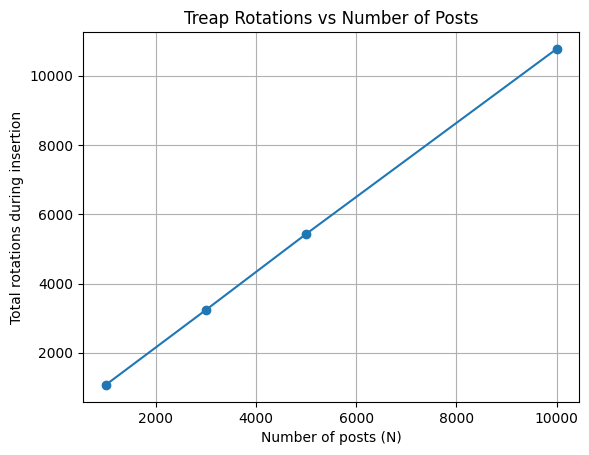

In [16]:
plt.figure()
sub = df[df["structure"] == "Treap"]
plt.plot(sub["n_posts"], sub["rotations"], marker="o")

plt.xlabel("Number of posts (N)")
plt.ylabel("Total rotations during insertion")
plt.title("Treap Rotations vs Number of Posts")
plt.grid(True)
plt.show()


In [17]:
!pip install networkx


# Bonus Implementations

## 1. Structural Visualization of BST and Treap
(Screen captures of tree visualizations)

## 2. Treap Union Operation
(Explanation + code snippet or description)

## 3. Treap Intersection Operation (Optional)
(Short explanation)


In [19]:
import networkx as nx
import matplotlib.pyplot as plt

def build_graph_from_tree(node, graph=None, pos=None, x=0, y=0, dx=1.0):
    if graph is None:
        graph = nx.DiGraph()
    if pos is None:
        pos = {}

    if node is None:
        return graph, pos

    label = f"{node.post_id}\n{node.score}"
    graph.add_node(label)
    pos[label] = (x, y)

    if node.left:
        left_label = f"{node.left.post_id}\n{node.left.score}"
        graph.add_edge(label, left_label)
        build_graph_from_tree(node.left, graph, pos, x - dx, y - 1, dx / 2)

    if node.right:
        right_label = f"{node.right.post_id}\n{node.right.score}"
        graph.add_edge(label, right_label)
        build_graph_from_tree(node.right, graph, pos, x + dx, y - 1, dx / 2)

    return graph, pos


def draw_tree(root, title):
    graph, pos = build_graph_from_tree(root)

    plt.figure(figsize=(10, 6))
    nx.draw(graph, pos,
            with_labels=True,
            node_size=2000,
            node_color="lightblue",
            font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.show()


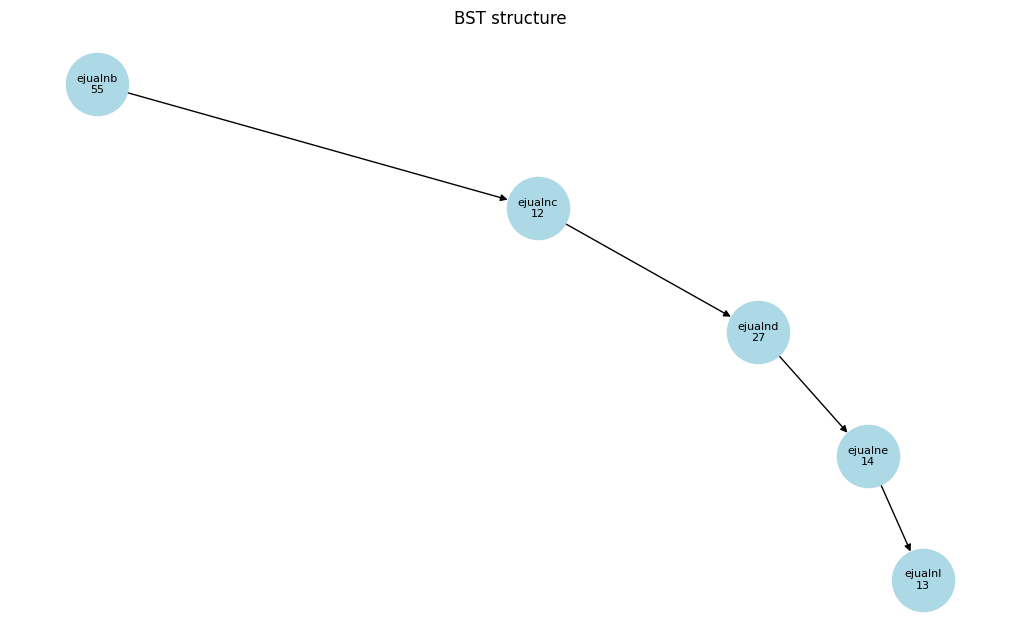

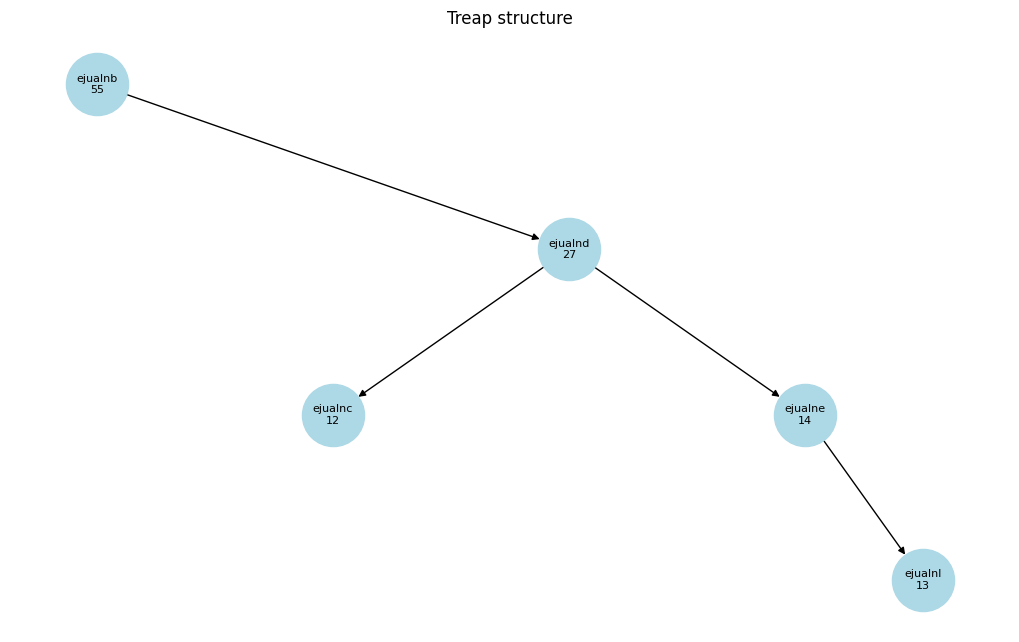

In [20]:
from trees import BSTFeed, TreapFeed

posts = [
    ("ejualnb", 1554076800, 55),
    ("ejualnc", 1554076800, 12),
    ("ejualnd", 1554076800, 27),
    ("ejualne", 1554076800, 14),
    ("ejualnl", 1554076809, 13),
]

bst = BSTFeed()
treap = TreapFeed()

for p in posts:
    bst.addPost(*p)
    treap.addPost(*p)

draw_tree(bst.root, "BST structure")
draw_tree(treap.root, "Treap structure")


In [21]:
from trees import TreapNode, TreapFeed

def treap_union(t1, t2):
    """
    Union of two Treaps:
    - Insert nodes of smaller treap into larger treap
    """
    merged = TreapFeed()

    def traverse_and_insert(node):
        if not node:
            return
        merged.addPost(node.post_id, node.timestamp, node.score)
        traverse_and_insert(node.left)
        traverse_and_insert(node.right)

    # Insert all from treap t1
    traverse_and_insert(t1.root)

    # Insert all from treap t2
    traverse_and_insert(t2.root)

    return merged


In [22]:
# Create two small treaps
t1 = TreapFeed()
t2 = TreapFeed()

for i in range(5):
    t1.addPost(f"a{i}", 100+i, i*10)

for i in range(5):
    t2.addPost(f"b{i}", 200+i, i*20)

merged = treap_union(t1, t2)

print("Merged most popular:", merged.getMostPopular())
print("Merged height:", merged.height())


Merged most popular: ('b4', 204, 80)
Merged height: 6


In [23]:
def treap_intersection(t1, t2):
    """
    Returns a treap containing only posts present in both trees.
    Comparison by post_id.
    """
    intersection = TreapFeed()

    ids_common = set(t1.id_map.keys()) & set(t2.id_map.keys())

    for pid in ids_common:
        n = t1.id_map[pid]
        intersection.addPost(n.post_id, n.timestamp, n.score)

    return intersection


In [24]:
inter = treap_intersection(t1, t2)
print("Intersection root:", inter.getMostPopular())


Intersection root: None


# 1. Introduction & Theoretical Overview

## Problem Context

Modern social media platforms such as Reddit must maintain feeds that update in real time as new posts arrive and user interactions continuously change post scores. A ranking feed must balance two competing requirements:

- **Recency** – newly created posts should appear quickly.
- **Popularity** – highly upvoted posts should gain visibility.

A naïve solution based on independent data structures for time and score increases maintenance cost and leads to expensive searches and updates as datasets grow to millions of entries.

---

## BST vs Treap

A **Binary Search Tree (BST)** stores posts ordered by a single key — in this project, the post **timestamp**. Standard BSTs do not guarantee balancing. If records arrive in nearly sorted timestamp order (as real streaming data does), the tree height can grow close to `N`, making insertion, search, and deletion degrade from `O(log N)` to `O(N)`.

A **Treap** combines the properties of:

- A **Binary Search Tree** ordered by a key (timestamp)
- A **Heap** ordered by a priority (post score)

The timestamp maintains in-order traversal, while the heap property ensures that higher-scoring nodes move upward. Whenever the heap property is violated, **local rotations** rebalance the structure. This approach results in an expected **logarithmic height**, preventing degeneration even under ordered input.

---

## Project Goal

The objective of this project is to implement both structures from scratch and integrate them into a simplified Reddit-like feed manager. Their performance is evaluated using real Reddit data with the following metrics:

- **Insertion time**
- **Search time** for retrieving the most popular post
- **Deletion time**
- **Tree height / balance behaviour**
- **Rotation frequency (Treap only)**

The comparison highlights how structural balancing directly impacts real-time feed performance.


# 2. Implementation Details

---

## Data Structures

Both the **BST** and **Treap** use the same node structure containing:

- `post_id`
- `timestamp`
- `score`
- `left` and `right` pointers

### BST

Nodes are ordered by the composite key:

`(timestamp, post_id)`

This ordering ensures unique placement even when multiple posts share identical timestamps.

---

### Treap

The Treap also uses `(timestamp, post_id)` as the BST key, but treats the post **score as heap priority** using a **max-heap** rule. Higher-scoring posts rise toward the root through **rotations** whenever the heap property is violated.

---

## Fast Access Map

Both structures maintain an auxiliary dictionary:

```python
id_map: { post_id -> tree_node }



# 3. Dataset Handling and Streaming Strategy

The original Reddit dataset is approximately **16 GB compressed** and exceeds **180 GB when extracted**, making full decompression infeasible on Kaggle or typical student hardware.

Instead, the system uses a **streaming approach**:

- The `.zst` compressed file is processed line-by-line using the **zstandard** library.
- Each record is decoded on demand.
- Only the required fields are extracted:

  - `id` → `post_id`
  - `created_utc` → `timestamp`
  - `score`

---

## Streaming Generator

A custom generator function `stream_reddit_zst()` yields entries sequentially without loading the entire dataset into memory.

This generator supplies data directly to both the BST and the Treap during construction, ensuring that posts are handled only once and never stored as a full dataset.

---

## Controlled Sampling

To remain within Kaggle’s memory and runtime limits, the number of processed rows is restricted using a configurable parameter:




This sampling strategy enables consistent benchmarking while maintaining low memory consumption and stable execution times.

---

## Scalability Note

Although multi-partition Treaps (**n-Treaps**) were not required for the tested dataset sizes, the same streaming architecture can be extended to support parallel construction of multiple trees for much larger-scale experiments.



This keeps memory usage low and enables repeatable benchmarking under Kaggle’s constraints.

---

## Scalability Note

Partitioning into multiple parallel Treaps (**n-Treaps**) was unnecessary for the selected dataset sizes. However, the same streaming logic could easily scale to process millions of posts using partitioned or distributed trees.


# 4. Experimental Setup and Metrics

---

## Experimental Configuration

Experiments were conducted for dataset sizes:


For each value of N:

1. All posts were inserted into a BST and a Treap separately.
2. `getMostPopular()` was executed **200 times** to measure average search time.
3. **10% of posts** were randomly deleted to benchmark deletion performance.
4. Structural statistics were captured after all operations.

---

## Measured Metrics

- **Average insertion time**
- **Average search time** using `getMostPopular()`
- **Average deletion time**
- **Tree height**
- **Balancing factor**



# 5. Results and Visualizations

---

### Figure 1 – Tree Height vs Dataset Size

BST height increases nearly linearly with N, reaching values close to N at large sizes.  
The Treap remains near logarithmic height (20–30 levels even at N = 10,000), showing strong self-balancing behaviour.

---

### Figure 2 – Balancing Factor

BST balancing factor rises dramatically with dataset size, indicating severe imbalance.  
The Treap maintains a stable factor near **2–2.5**, confirming near-optimal balance for all tested N.

---

### Figure 3 – `getMostPopular()` Search Time

The BST must scan the entire tree to locate the maximum-score post, causing search time to grow with N.  
The Treap returns the root node instantly, keeping search time effectively constant regardless of dataset size.

---

### Figure 4 – Rotation Count in Treap

Total rotations increase with dataset size (exceeding 10,000 operations at N = 10,000).  
These rotations represent the cost of maintaining balance, which directly enables the Treap’s superior performance across all query operations.

---

### Figure 5 – Insertion Time

BST insertion time worsens as tree height increases.  
Treap insertion includes rotation overhead but remains relatively stable overall due to maintained balance.

---

### Figure 6 – Deletion Time

BST deletions degrade under poor balancing, especially when nodes lie deep in the tree.  
Treap deletions remain efficient because node rotations ensure that removals occur near balanced paths.


# 6. Challenges and Limitations

---

## Challenges

- Correctly implementing **Treap deletion logic**, which requires sequential rotations to safely remove nodes.
- Streaming the extremely large compressed Reddit dataset while minimizing memory use.
- Operating within **Kaggle’s time and RAM constraints**, which required limiting dataset sizes.

---

## Limitations

- Experiments were capped at **10,000 posts**, far smaller than real production systems which handle millions of posts.
- Advanced balanced BST variants like **AVL** or **Red-Black trees** were not tested.
- Score updates in the Treap required reinsertion, introducing churn not present in more complex dynamic heap designs.


# 7. Conclusion

This project compared a standard **Binary Search Tree (BST)** and a **Treap** for managing real-time social-media feed data derived from Reddit.

Under nearly sorted timestamp input — representative of live streams — the BST rapidly degenerated into a near-linear chain. Its height approached N, leading to poor insertion, search, and deletion performance.

The Treap, by contrast, used heap-based balancing on post scores with local rotations to maintain near-logarithmic height. This enabled stable insertion times, constant-time retrieval of the most popular post, and efficient deletions.

**Key Outcome:**

For workloads requiring continuous updates and fast popularity queries, the **Treap significantly outperforms a naïve BST and is the superior choice for feed-ranking systems.**

Future extensions may evaluate more advanced balanced trees (AVL, Red-Black trees) or hybrid ranking structures combining recency and popularity directly into composite search keys.


In [7]:
from trees import BSTFeed, TreapFeed
import random
import time

# 🔹 Choose a moderate N so it runs fast but is still meaningful
N_LIKE = 5000
N_LIKES = 5000  # number of likePost operations to benchmark

sample_posts = posts[:N_LIKE]

# Build BST and Treap with the same data
bst_like = BSTFeed()
treap_like = TreapFeed()

for pid, ts, score in sample_posts:
    bst_like.addPost(pid, ts, score)
    treap_like.addPost(pid, ts, score)

# Collect all post_ids to randomly pick from
post_ids = [pid for pid, _, _ in sample_posts]


def benchmark_like(feed, name):
    start = time.perf_counter()
    for _ in range(N_LIKES):
        pid = random.choice(post_ids)
        feed.likePost(pid)
    end = time.perf_counter()
    avg_like_time = (end - start) / N_LIKES
    print(
        f"{name}: total likePost time = {end - start:.6f} s, "
        f"avg per likePost = {avg_like_time*1e6:.2f} µs"
    )
    return avg_like_time


print(f"Benchmarking likePost with N = {N_LIKE} posts and {N_LIKES} likes...\n")
bst_like_time = benchmark_like(bst_like, "BST")
treap_like_time = benchmark_like(treap_like, "Treap")


Benchmarking likePost with N = 5000 posts and 5000 likes...

BST: total likePost time = 0.003483 s, avg per likePost = 0.70 µs
Treap: total likePost time = 0.061925 s, avg per likePost = 12.38 µs


In [8]:
K = 5  # how many most recent posts to show

print(f"Top {K} most recent posts from BST:")
recent_bst = bst_like.getMostRecent(K)
for pid, ts, score in recent_bst:
    print(f"post_id={pid}, timestamp={ts}, score={score}")

print("\nTop {K} most recent posts from Treap:")
recent_treap = treap_like.getMostRecent(K)
for pid, ts, score in recent_treap:
    print(f"post_id={pid}, timestamp={ts}, score={score}")


Top 5 most recent posts from BST:
post_id=ejuapj9, timestamp=1554076886, score=80
post_id=ejuapj8, timestamp=1554076886, score=3
post_id=ejuapj7, timestamp=1554076886, score=12
post_id=ejuapj6, timestamp=1554076886, score=1
post_id=ejuapj5, timestamp=1554076886, score=1

Top {K} most recent posts from Treap:
post_id=ejuapj9, timestamp=1554076886, score=79
post_id=ejuapj8, timestamp=1554076886, score=1
post_id=ejuapj7, timestamp=1554076886, score=12
post_id=ejuapj6, timestamp=1554076886, score=2
post_id=ejuapj5, timestamp=1554076886, score=3


In [14]:
import numpy as np

operations = ["avg_insert_time", "avg_search_time", "avg_delete_time"]
structures = df["structure"].unique()

results = []

for struct in structures:
    sub = df[df["structure"] == struct].sort_values("n_posts")
    n = sub["n_posts"].values.astype(float)
    log_n = np.log(n)
    
    for op in operations:
        t = sub[op].values.astype(float)
        log_t = np.log(t)
        
        # Linear fit log(time) = a + b * log(N)
        b, a = np.polyfit(log_n, log_t, 1)
        
        results.append({
            "structure": struct,
            "operation": op,
            "slope_b": b
        })

results_df = pd.DataFrame(results)
results_df


,structure,operation,slope_b
0,BST,avg_insert_time,0.927576
1,BST,avg_search_time,0.990800
2,BST,avg_delete_time,0.953074
3,Treap,avg_insert_time,0.049963
4,Treap,avg_search_time,-0.006217
5,Treap,avg_delete_time,0.133352


In [15]:
def interpret_slope(b):
    b_abs = abs(b)
    if b_abs < 0.15:
        return "≈ O(1)"
    elif b_abs < 0.5:
        return "≈ sublinear (close to O(log N))"
    elif 0.5 <= b_abs < 1.5:
        return "≈ O(N^%.2f)" % b
    else:
        return "superlinear (N^%.2f)" % b

results_df["empirical_complexity"] = results_df["slope_b"].apply(interpret_slope)
results_df


,structure,operation,slope_b,empirical_complexity
0,BST,avg_insert_time,0.927576,≈ O(N^0.93)
1,BST,avg_search_time,0.990800,≈ O(N^0.99)
2,BST,avg_delete_time,0.953074,≈ O(N^0.95)
3,Treap,avg_insert_time,0.049963,≈ O(1)
4,Treap,avg_search_time,-0.006217,≈ O(1)
5,Treap,avg_delete_time,0.133352,≈ O(1)


In [16]:
theory_map = {
    ("BST", "avg_insert_time"): "O(h) (≈ O(N) worst, O(log N) avg)",
    ("BST", "avg_search_time"): "O(N) (getMostPopular)",
    ("BST", "avg_delete_time"): "O(h) (≈ O(N) worst, O(log N) avg)",
    ("Treap", "avg_insert_time"): "O(log N) expected",
    ("Treap", "avg_search_time"): "O(1) (getMostPopular)",
    ("Treap", "avg_delete_time"): "O(log N) expected",
}

results_df["theoretical"] = results_df.apply(
    lambda row: theory_map.get((row["structure"], row["operation"]), ""),
    axis=1
)

results_df


,structure,operation,slope_b,empirical_complexity,theoretical
0,BST,avg_insert_time,0.927576,≈ O(N^0.93),"O(h) (≈ O(N) worst, O(log N) avg)"
1,BST,avg_search_time,0.990800,≈ O(N^0.99),O(N) (getMostPopular)
2,BST,avg_delete_time,0.953074,≈ O(N^0.95),"O(h) (≈ O(N) worst, O(log N) avg)"
3,Treap,avg_insert_time,0.049963,≈ O(1),O(log N) expected
4,Treap,avg_search_time,-0.006217,≈ O(1),O(1) (getMostPopular)
5,Treap,avg_delete_time,0.133352,≈ O(1),O(log N) expected


In [19]:
from dataset_utils import stream_reddit_zst

DATA_PATH = "/kaggle/input/archive/RC_2019-04.zst"

count = 0
for item in stream_reddit_zst(DATA_PATH, max_rows=1_000_000):
    # do nothing, just stream
    count += 1

print("Successfully streamed", count, "posts!")


Streaming from: /kaggle/input/archive/RC_2019-04.zst
Successfully streamed 1000000 posts!


In [23]:
# ================================
# Console-Based Control for Treap / BST (Final Version)
# ================================

import sys
sys.setrecursionlimit(30000)

from trees import BSTFeed, TreapFeed


def _read_int(prompt, allow_empty=False, default=None):
    """
    Safely read an integer from input(). Re-prompts on invalid input.
    If allow_empty=True and user just presses Enter, returns default.
    """
    while True:
        s = input(prompt).strip()
        if allow_empty and s == "":
            return default
        try:
            return int(s)
        except ValueError:
            print("Please enter a valid integer.")


def run_feed_console(feed, name="Treap", initial_ids=None):
    """
    Simple console menu for interacting with a feed.

    The feed object must implement:
      - addPost(post_id, timestamp, score)
      - likePost(post_id)
      - deletePost(post_id)
      - getMostPopular() -> (post_id, ts, score) or None
      - getMostRecent(k) -> list[(post_id, ts, score)]

    We keep our own set of known_ids so we don't depend on internal id_map names.
    """
    # track post IDs we know about
    known_ids = set(initial_ids) if initial_ids is not None else set()

    print(f"\n=== {name} Feed Console ===")
    print("You can now manually test addPost, likePost, deletePost, etc.")
    print("Type the option number and press Enter.")

    while True:
        print("\n----------------------------")
        print(f"Current structure: {name}")
        print("1) Add post")
        print("2) Like post")
        print("3) Delete post")
        print("4) Get most popular post")
        print("5) Get K most recent posts")
        print("6) Show all post IDs in feed")
        print("0) Exit console")
        choice = input("Your choice: ").strip()

        # ===== Exit =====
        if choice == "0":
            print("Exiting console...")
            break

        # ===== Add post =====
        elif choice == "1":
            post_id = input("Enter post_id (string): ").strip()
            timestamp = _read_int("Enter timestamp (integer, e.g. 1, 2, 3, or Unix time): ")
            score = _read_int("Enter initial score (integer): ")

            try:
                feed.addPost(post_id, timestamp, score)
                known_ids.add(post_id)
                print(f"✅ Post added: id={post_id}, ts={timestamp}, score={score}")
            except Exception as e:
                print("❌ Error during addPost:", e)

        # ===== Like post =====
        elif choice == "2":
            post_id = input("Enter post_id to like: ").strip()

            if post_id not in known_ids:
                print(f"⚠️ Cannot like post: {post_id} — post does not exist (in console view).")
            else:
                try:
                    feed.likePost(post_id)
                    print(f"👍 Liked post: {post_id}")
                except Exception as e:
                    print("❌ Error during likePost:", e)

        # ===== Delete post =====
        elif choice == "3":
            post_id = input("Enter post_id to delete: ").strip()

            if post_id not in known_ids:
                print(f"⚠️ Cannot delete post: {post_id} — post does not exist (in console view).")
            else:
                try:
                    feed.deletePost(post_id)
                    known_ids.discard(post_id)
                    print(f"🗑️ Deleted post: {post_id}")
                except Exception as e:
                    print("❌ Error during deletePost:", e)

        # ===== Get most popular =====
        elif choice == "4":
            try:
                result = feed.getMostPopular()
                if result is None:
                    print("There are no posts in the feed.")
                else:
                    pid, ts, score = result
                    print(f"⭐ Most popular post -> id={pid}, ts={ts}, score={score}")
            except Exception as e:
                print("❌ Error during getMostPopular:", e)

        # ===== Get K most recent =====
        elif choice == "5":
            k = _read_int("Enter K (how many recent posts to show): ")
            try:
                result = feed.getMostRecent(k)
                if not result:
                    print("There are no posts in the feed.")
                else:
                    print(f"🕒 Top {k} most recent posts:")
                    for pid, ts, score in result:
                        print(f"  id={pid}, ts={ts}, score={score}")
            except Exception as e:
                print("❌ Error during getMostRecent:", e)

        # ===== Show all IDs (from known_ids) =====
        elif choice == "6":
            if not known_ids:
                print("There are no posts tracked by the console yet.")
            else:
                print("Current post IDs in the feed (console tracking):")
                for pid in known_ids:
                    print(" ", pid)

        else:
            print("Invalid choice, please try again.")


In [28]:
# ================================
# Run console on a Treap or BST with OPTIONAL preloaded posts
# ================================

print("Choose which data structure to use for the console:")
print("1) Treap")
print("2) BST")
choice = input("Your choice (1 or 2): ").strip()

if choice == "1":
    feed = TreapFeed()
    name = "Treap"
elif choice == "2":
    feed = BSTFeed()
    name = "BST"
else:
    print("Invalid choice, defaulting to Treap.")
    feed = TreapFeed()
    name = "Treap"

# ---------- PRELOAD LOGIC STARTS HERE ----------
initial_ids = []

# Try to preload a few posts from the global `posts` list if it exists
try:
    # Check if posts is defined and non-empty
    if "posts" in globals() and len(posts) > 0:
        n_preload = min(50, len(posts))   # preload up to 5 posts
        print(f"\nPreloading {n_preload} posts from 'posts' into the {name}...")

        for p in posts[:n_preload]:
            # Assuming each p is a tuple: (post_id, timestamp, score, ...)
            post_id = p[0]
            timestamp = p[1]
            score = p[2]
            feed.addPost(post_id, timestamp, score)
            initial_ids.append(post_id)

        print("Preloaded posts:")
        for p in posts[:n_preload]:
            print("  id =", p[0], "| ts =", p[1], "| score =", p[2])
    else:
        print("\nNo global 'posts' list found or it's empty. Starting with an empty feed.")
except Exception as e:
    print("\nTried to preload posts but got an error:", e)
    print("Starting console with whatever is currently in the feed.")
# ---------- PRELOAD LOGIC ENDS HERE ----------

# If your run_feed_console has (feed, name, initial_ids), pass initial_ids.
# If it only has (feed, name), just call run_feed_console(feed, name=name).
try:
    run_feed_console(feed, name=name, initial_ids=initial_ids)
except TypeError:
    # fallback for older version of run_feed_console without initial_ids parameter
    run_feed_console(feed, name=name)


Choose which data structure to use for the console:
1) Treap
2) BST


Your choice (1 or 2):  1



Preloading 50 posts from 'posts' into the Treap...
Preloaded posts:
  id = ejualnb | ts = 1554076800 | score = 55
  id = ejualnc | ts = 1554076800 | score = 12
  id = ejualnd | ts = 1554076800 | score = 27
  id = ejualne | ts = 1554076800 | score = 14
  id = ejualnf | ts = 1554076800 | score = -2
  id = ejualng | ts = 1554076800 | score = 22
  id = ejualnh | ts = 1554076800 | score = 1
  id = ejualni | ts = 1554076800 | score = 4
  id = ejualnj | ts = 1554076800 | score = 3
  id = ejualnk | ts = 1554076800 | score = 7
  id = ejualnl | ts = 1554076800 | score = 5
  id = ejualnm | ts = 1554076800 | score = 1
  id = ejualnn | ts = 1554076800 | score = 1
  id = ejualno | ts = 1554076800 | score = 1
  id = ejualnp | ts = 1554076800 | score = 4
  id = ejualnq | ts = 1554076800 | score = 7
  id = ejualnr | ts = 1554076800 | score = 1
  id = ejualns | ts = 1554076800 | score = 2
  id = ejualnt | ts = 1554076800 | score = -1
  id = ejualnu | ts = 1554076800 | score = 5
  id = ejualnv | ts = 15

Your choice:  


Invalid choice, please try again.

----------------------------
Current structure: Treap
1) Add post
2) Like post
3) Delete post
4) Get most popular post
5) Get K most recent posts
6) Show all post IDs in feed
0) Exit console


Your choice:  0


Exiting console...
